Inspecting dataset images to better adapt for predictions

In [2]:
%pip install Pillow opencv-python

Note: you may need to restart the kernel to use updated packages.


In [1]:
from PIL import Image
import os

In [5]:
def check_image_color_mode(img :Image):
    """Checks if an image is RGB or grayscale."""
    try:
        mode = img.mode
        if mode == 'RGB':
            return 'RGB'
        elif mode == 'L':  # 'L' mode represents grayscale
            return 'Grayscale'
        else:
            return f'Other ({mode})'  # Handle other color modes if necessary
    except Exception as e:
        return f"Error: {e}"

def check_dataset_images(dataset_folder):
    """Checks color modes of all images in a folder."""
    for filename in os.listdir(dataset_folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            image_path = os.path.join(dataset_folder, filename)
            image = Image.open(image_path)
            color_mode = check_image_color_mode(image)
            print(f"{filename}: {color_mode}")

dataset_folder = 'BuilderFormer-4-4/valid/images'
check_dataset_images(dataset_folder)

APT_FP_SPA_034570688_PNG_jpg.rf.2559ee1af6f51c4a3dbebc34b0eb4a25.jpg: RGB
APT_FP_SPA_034570688_PNG_jpg.rf.afa45fcb3a51ee056da0a725c5244615.jpg: RGB
APT_FP_SPA_036906529_PNG_jpg.rf.f45e0252785ed0b8e7a4e1fa733759e4.jpg: RGB
APT_FP_SPA_037105612_PNG_jpg.rf.d9e9343ba7150b18c9a403629375d040.jpg: RGB
APT_FP_SPA_038082282_PNG_jpg.rf.f476cbe1ea2d894a22bdffbd717cb605.jpg: RGB
APT_FP_SPA_041684981_PNG_jpg.rf.aed1167966a26eccaaed22fb726ea28c.jpg: RGB
APT_FP_SPA_043277517_PNG_jpg.rf.4876e9e38ce3d8eccf396a745f710462.jpg: RGB
APT_FP_SPA_053461291_PNG_jpg.rf.c3db0fb52e47c9a7f5a0a2807ffbe8b7.jpg: RGB
APT_FP_SPA_054208404_PNG_jpg.rf.73ffecd4387ecb7a6faf9e7778993782.jpg: RGB
APT_FP_SPA_057345978_PNG_jpg.rf.67e9a04323e197ec88ceb1dc98adb9bb.jpg: RGB
APT_FP_SPA_057917679_PNG_jpg.rf.a449240d8dd8cecd5cab23af268ff932.jpg: RGB
APT_FP_SPA_060628957_PNG_jpg.rf.8546fe96edcf57d39b490f79d774c36a.jpg: RGB
APT_FP_SPA_060628957_PNG_jpg.rf.b0a90ded02600de9022f0a51986fc750.jpg: RGB
APT_FP_SPA_063117754_PNG_jpg.rf.61419f

Adjusting the test image

In [2]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


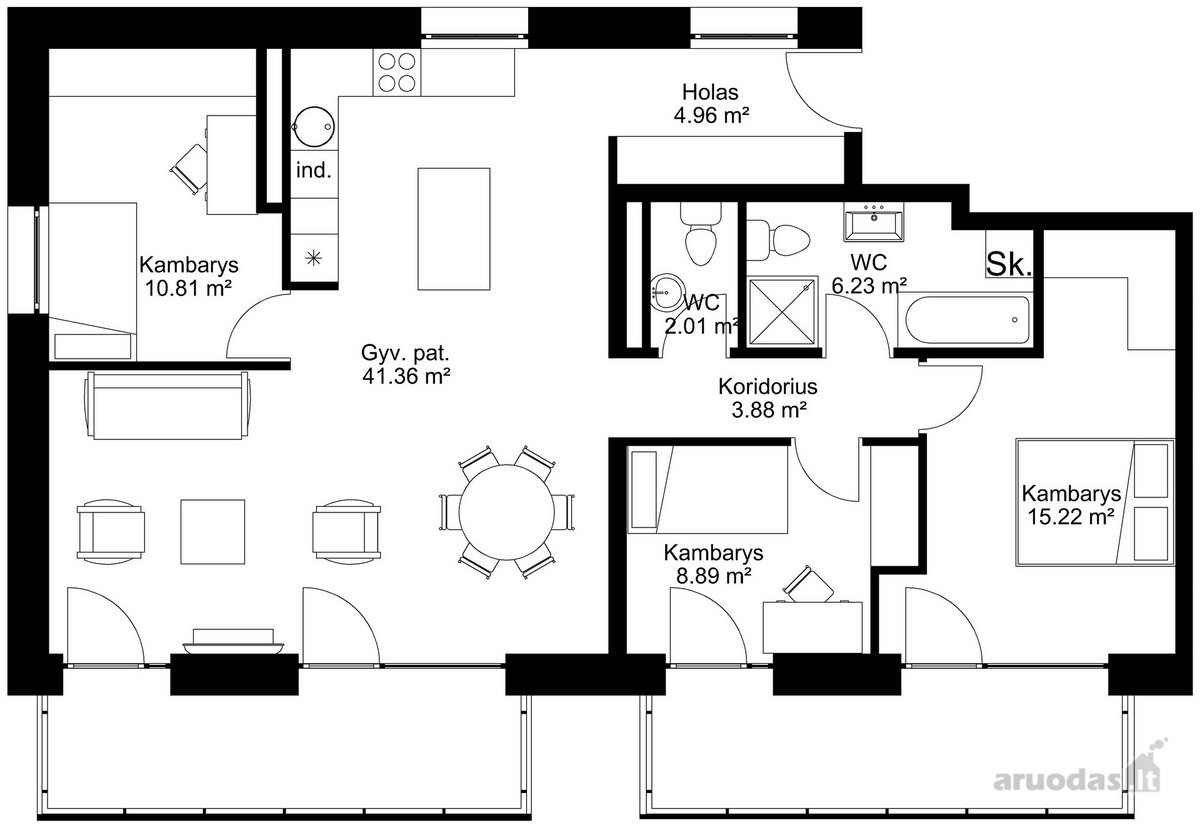

(1200, 828)
RGB


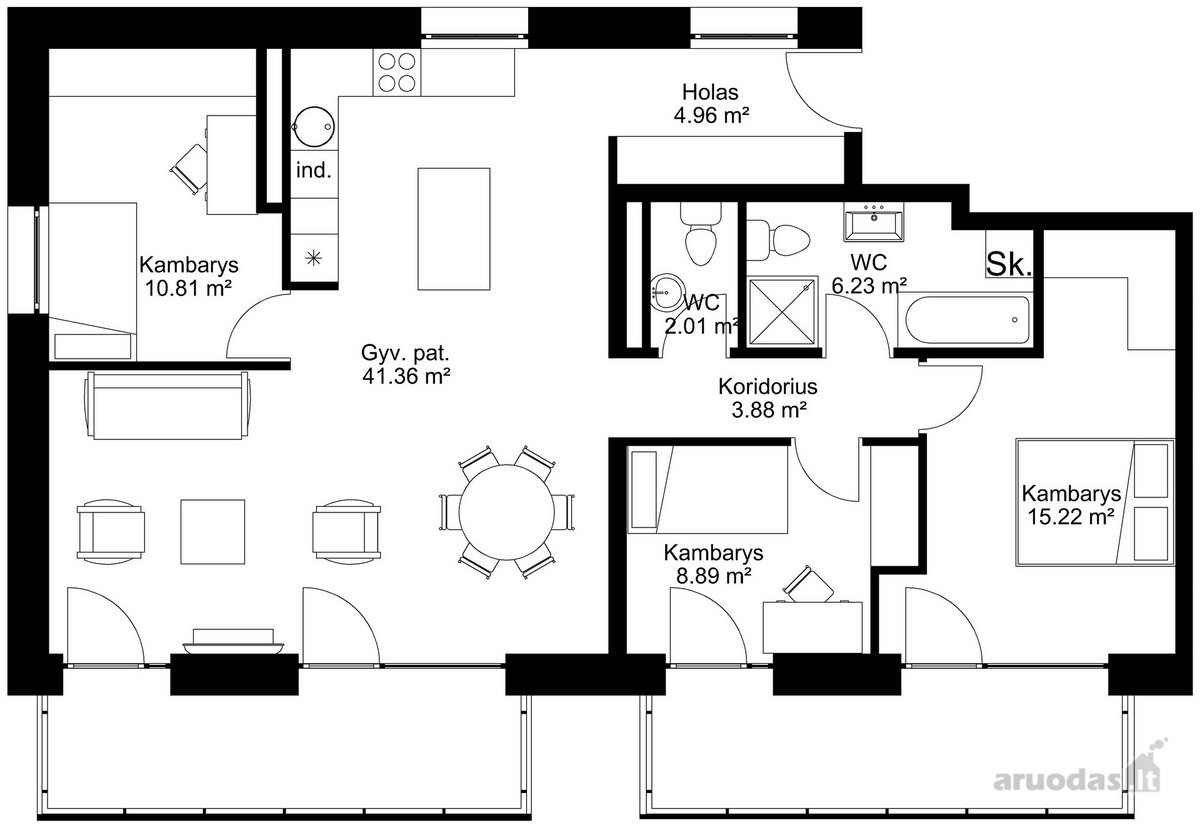

(1200, 828)


AttributeError: module 'PIL.Image' has no attribute 'ANTIALIAS'

In [7]:
import cv2
import numpy as np

new_size = (640, 640) #based on the trainin data size

def pre_process(image : Image, size = (640, 640)):
    """Pre-processes the image to the same standards as the training data"""

    #converting to rgb if not rgb
    color_mode = check_image_color_mode(image)
    print(color_mode)
    if color_mode != "RGB":
        image = image.convert("RGB") 

    #stripping auto-rotation
    data = list(image.getdata())
    image_stripped = Image.new(image.mode, image.size)
    image_stripped.putdata(data)

    display(image_stripped)
    print(image_stripped.size)

    #resizing
    old_size = image_stripped.size  # old_size[0] is in (width, height) format

    ratio = float(size[0])/max(old_size)
    new_size = tuple([int(x*ratio) for x in old_size])
    image_stripped.thumbnail(new_size, Image.ANTIALIAS)

    #im = im.resize(new_size, Image.ANTIALIAS)
    # create a new image and paste the resized on it

    new_im = Image.new("RGB", size)
    new_im.paste(image_stripped, ((size[0]-new_size[0])//2,
                        (size[1]-new_size[1])//2))

    new_im.show()

#adjust the size

image_loc = "my_custom/image (16).png"
img_test = Image.open(image_loc)
display(img_test)
print(img_test.size)

pre_process(img_test)


In [ ]:
%pip install ultralytics

In [ ]:
from ultralytics import YOLO

model_link = "C:\Users\Linos\Documents\Coding_practice\Dirbtinis Intelektas ir Python\Intelligent-Architecture\runs\detect\train4\weights\best.pt"
test_link = ""

model = YOLO(model_link)
result = model.predict(test_link)